In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RELATIONS = ["front", "behind", "left", "right"]

TRUE_LABEL_GROUPS = {
    "front_behind": ["front", "behind"],
    "left_right": ["left", "right"]
}

def extract_camera_perspective(image_path):
    image_path = str(image_path)
    filename = os.path.basename(image_path).lower()

    m = re.search(r'_(front|behind|left|right)_of_', filename)
    if m:
        return m.group(1)
    return None

def extract_letter_to_relation(prompt):
    """
    从 mcq_prompt 中解析 A/B/C/D 分别对应哪个方向。
    要求 prompt 里包含类似：
    A. ...front...
    B. ...behind...
    C. ...left...
    D. ...right...
    顺序可打乱。
    """
    prompt = str(prompt)

    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        # 提取当前选项文字，直到下一个选项字母或字符串结束
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue

        text = m.group(1).lower()

        if "front" in text:
            mapping[letter] = "front"
        elif "behind" in text:
            mapping[letter] = "behind"
        elif "left" in text:
            mapping[letter] = "left"
        elif "right" in text:
            mapping[letter] = "right"

    return mapping


def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)

    def get_pred_relation(row):
        letter_map = extract_letter_to_relation(row["mcq_prompt"])
        pred_letter = str(row["pred_letter"]).strip()
        return letter_map.get(pred_letter, None)

    df["pred_relation"] = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    df["camera_perspective"] = df["image_path"].apply(extract_camera_perspective)

    return df


def analyze_percentages(df):
    rows = []

    for rel in RELATIONS:
        sub = df[df["correct_relation"] == rel]
        total = len(sub)

        if total == 0:
            rows.append({
                "correct_relation": rel,
                "total": 0,
                "correct_pct": 0.0,
                "opposite_pct": 0.0
            })
            continue

        correct = (sub["pred_letter"].astype(str).str.strip() == sub["correct_letter"].astype(str).str.strip()).sum()
        opposite = (sub["pred_letter"].astype(str).str.strip() == sub["opposite_letter"].astype(str).str.strip()).sum()

        rows.append({
            "correct_relation": rel,
            "total": total,
            "correct_pct": correct / total,
            "opposite_pct": opposite / total
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix(df, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        plt.show()
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            val = cm_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.colorbar(im, ax=ax)
    plt.show()


def analyze_one_file(csv_path, title=None):
    df = load_and_prepare(csv_path)
    pct_df = analyze_percentages(df)

    if title is None:
        title = os.path.basename(csv_path)

    print(f"\n===== {title} =====")
    display(pct_df)

    plot_confusion_matrix(
        df,
        title=f"{title} - true: front/behind",
        true_labels=TRUE_LABEL_GROUPS["front_behind"]
    )
    plot_confusion_matrix(
        df,
        title=f"{title} - true: left/right",
        true_labels=TRUE_LABEL_GROUPS["left_right"]
    )

    return df, pct_df



def plot_confusion_on_ax(df, ax, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            val = cm_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")


In [ ]:
# def analyze_camera_bias(df):
#     """
#     对每个 correct_relation，统计：
#     - correct_pct
#     - camera_pct: 预测落到 camera perspective 的比例
#     - other_pct: 不属于上面二者的比例
#     """
#     rows = []

#     for rel in RELATIONS:
#         sub = df[
#             (df["correct_relation"] == rel) &
#             (df["pred_relation"].isin(RELATIONS)) &
#             (df["camera_perspective"].isin(RELATIONS))
#         ].copy()

#         total = len(sub)

#         if total == 0:
#             rows.append({
#                 "correct_relation": rel,
#                 "total": 0,
#                 "correct_pct": 0.0,
#                 "camera_pct": 0.0,
#                 "other_pct": 0.0
#             })
#             continue

#         correct = (sub["pred_relation"] == sub["correct_relation"]).sum()
#         camera = (sub["pred_relation"] == sub["camera_perspective"]).sum()

#         # other = 不等于 correct，且不等于 camera
#         other = (
#             (sub["pred_relation"] != sub["correct_relation"]) &
#             (sub["pred_relation"] != sub["camera_perspective"])
#         ).sum()

#         rows.append({
#             "correct_relation": rel,
#             "total": total,
#             "correct_pct": correct / total,
#             "camera_pct": camera / total,
#             "other_pct": other / total
#         })

#     return pd.DataFrame(rows)


# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# BIAS_LABELS = ["camera", "correct", "other"]


# def build_camera_confusion(df):

#     rows = df[
#         df["pred_relation"].isin(RELATIONS) &
#         df["camera_perspective"].isin(RELATIONS)
#     ].copy()

#     gt_labels = []
#     pred_labels = []

#     for _, r in rows.iterrows():

#         correct = r["correct_relation"]
#         camera = r["camera_perspective"]
#         pred = r["pred_relation"]

#         # ground truth category
#         if camera == correct:
#             gt = "correct"
#         else:
#             gt = "camera"

#         # predicted category
#         if pred == correct:
#             pr = "correct"
#         elif pred == camera:
#             pr = "camera"
#         else:
#             pr = "other"

#         gt_labels.append(gt)
#         pred_labels.append(pr)

#     cm = confusion_matrix(
#         gt_labels,
#         pred_labels,
#         labels=BIAS_LABELS
#     )

#     return cm



# def plot_camera_confusion(df, ax, title):

#     cm = build_camera_confusion(df)

#     disp = ConfusionMatrixDisplay(
#         confusion_matrix=cm,
#         display_labels=BIAS_LABELS
#     )

#     disp.plot(
#         ax=ax,
#         cmap="Blues",
#         values_format="d",
#         colorbar=False
#     )

#     ax.set_title(title)

In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

RELATIONS = ["front", "behind", "left", "right"]
OBJECT_POSITIONS = ["left", "right"]  # the two splits you want


def extract_camera_perspective(image_path):
    image_path = str(image_path)
    filename = os.path.basename(image_path).lower()
    m = re.search(r'_(front|behind|left|right)_of_', filename)
    if m:
        return m.group(1)
    return None


def extract_object_position(image_path):
    """
    Extract the object's spatial position from the filename.
    Format: {obj1}_{position}_of_{obj2}_{camera}.png
    e.g. shoes_right_of_chair_FACE-RIGHT.png  →  'right'
         shoes_left_of_chair_FACE-LEFT.png    →  'left'
    """
    image_path = str(image_path)
    filename = os.path.basename(image_path).lower()
    m = re.search(r'_(left|right)_of_', filename)
    if m:
        return m.group(1)
    return None


def extract_letter_to_relation(prompt):
    prompt = str(prompt)
    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue
        text = m.group(1).lower()
        if "front" in text:
            mapping[letter] = "front"
        elif "behind" in text:
            mapping[letter] = "behind"
        elif "left" in text:
            mapping[letter] = "left"
        elif "right" in text:
            mapping[letter] = "right"
    return mapping


def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)

    def get_pred_relation(row):
        letter_map = extract_letter_to_relation(row["mcq_prompt"])
        pred_letter = str(row["pred_letter"]).strip()
        return letter_map.get(pred_letter, None)

    df["pred_relation"] = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    df["camera_perspective"] = df["image_path"].apply(extract_camera_perspective)
    df["object_position"] = df["image_path"].apply(extract_object_position)  # NEW

    return df


def plot_confusion_on_ax(df, ax, title):
    """
    4×4 confusion matrix: rows = true relation, cols = predicted relation.
    All four directions on both axes.
    """
    plot_df = df[
        df["correct_relation"].isin(RELATIONS) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=RELATIONS, columns=RELATIONS, fill_value=0.0)

    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(RELATIONS)))
    ax.set_yticklabels(RELATIONS)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            val = cm_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if val > 0.6 else "black")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    return im


def analyze_one_file(csv_path, title=None):
    df = load_and_prepare(csv_path)

    if title is None:
        title = os.path.basename(csv_path)

    print(f"\n===== {title} =====")

    # 2 columns: one per object position (left / right)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle(title, fontsize=12)

    last_im = None
    for ax, obj_pos in zip(axes, OBJECT_POSITIONS):
        sub = df[df["object_position"] == obj_pos]
        im = plot_confusion_on_ax(
            sub, ax,
            title=f"object position = {obj_pos}\n(n={len(sub)})"
        )
        if im is not None:
            last_im = im

    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.8)

    plt.tight_layout()
    plt.show()

    return df


### draw all, each in 1 figure

MODEL: internvl


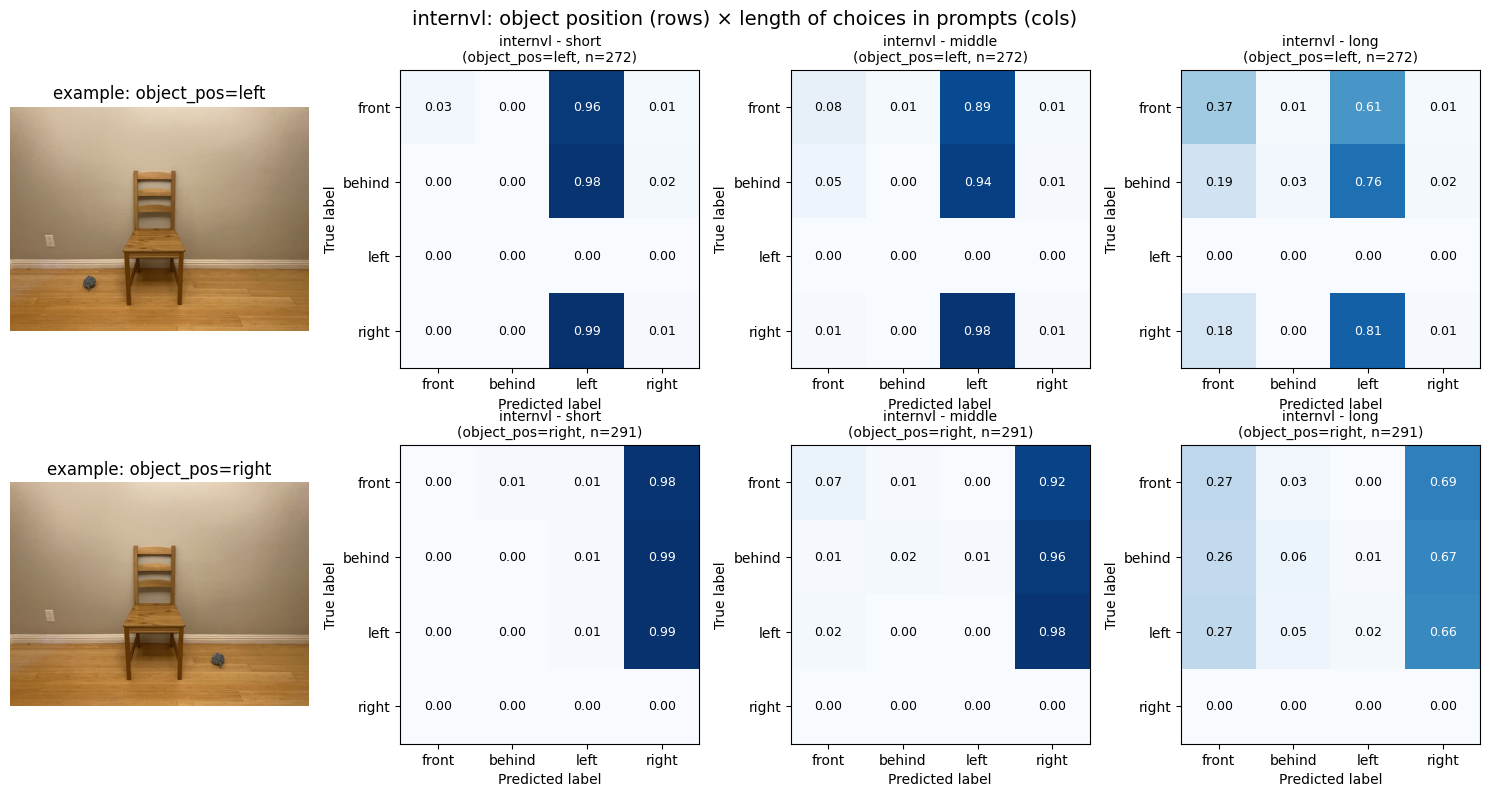

MODEL: qwen3vl


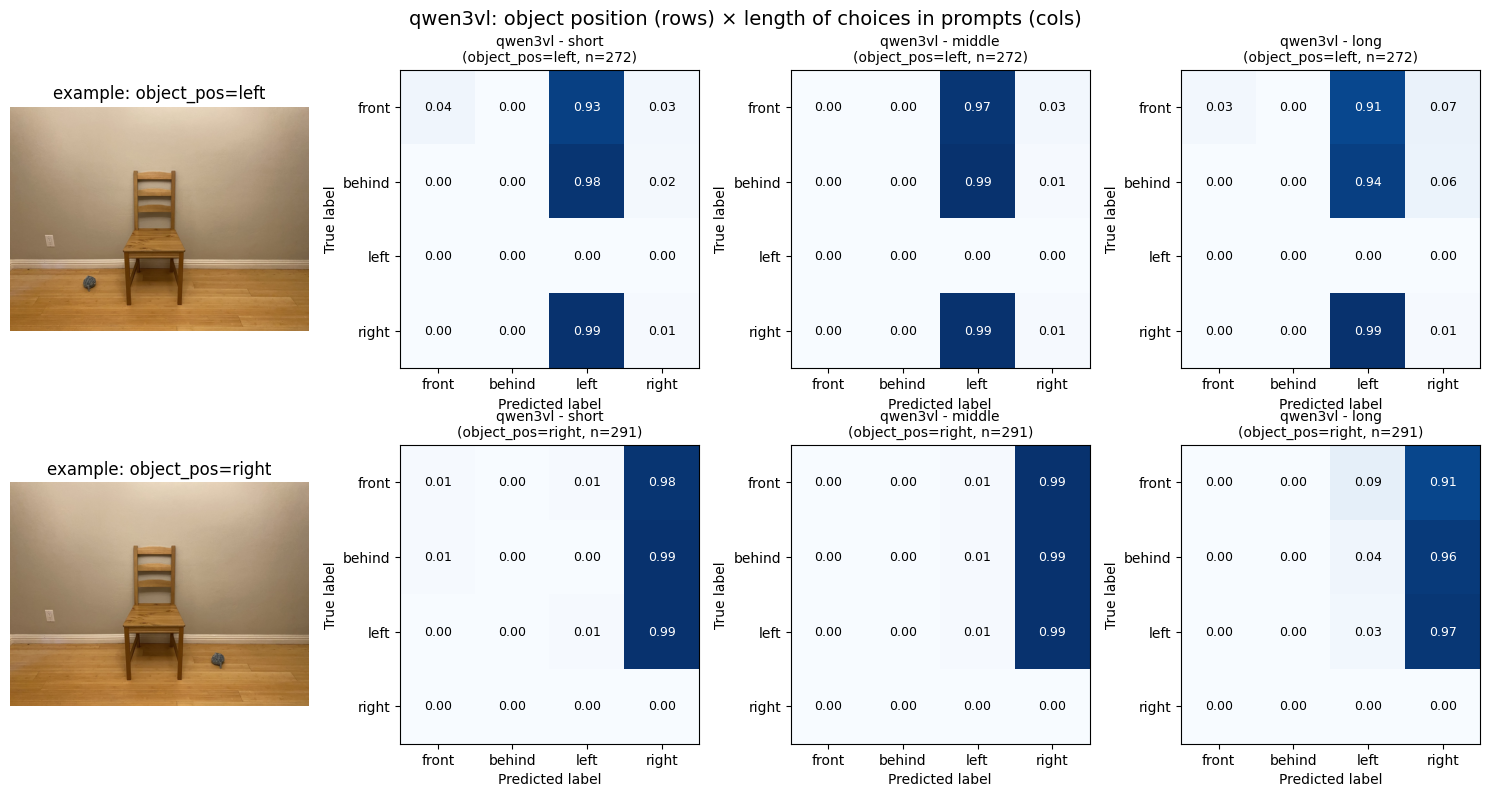

MODEL: qwen3vl_thinking


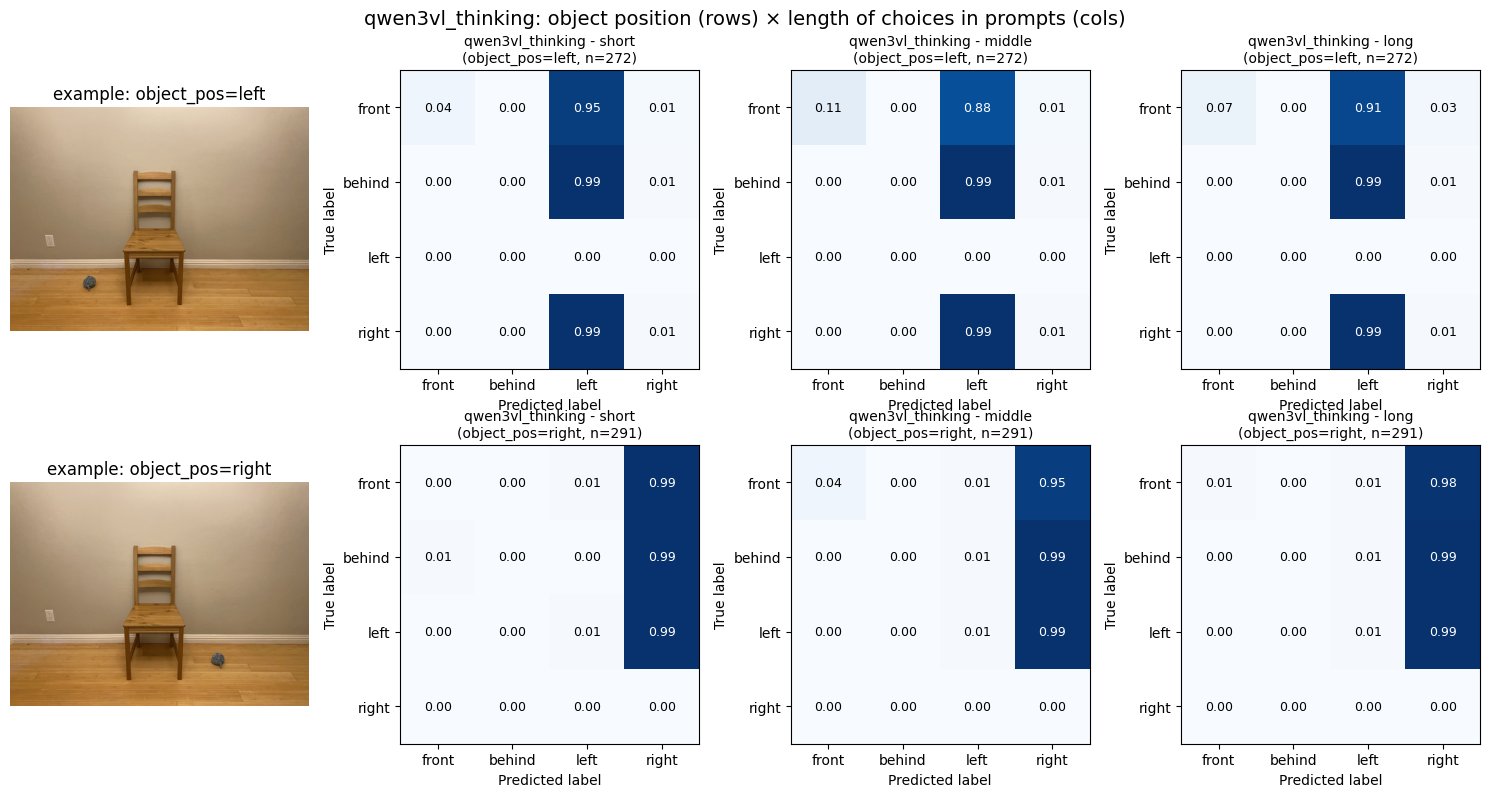

MODEL: qwen3.5


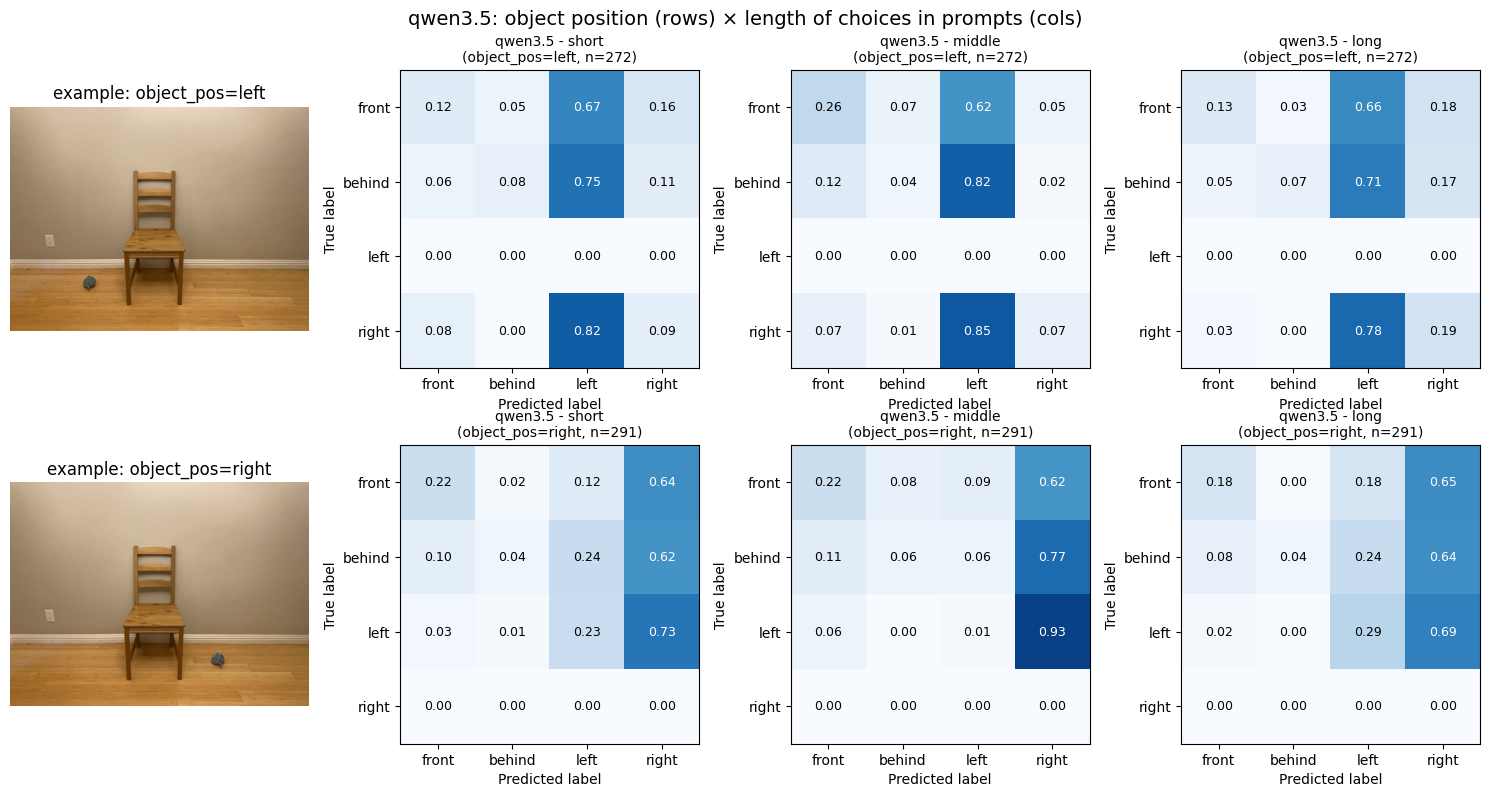

MODEL: qwen3_5vl_thinking


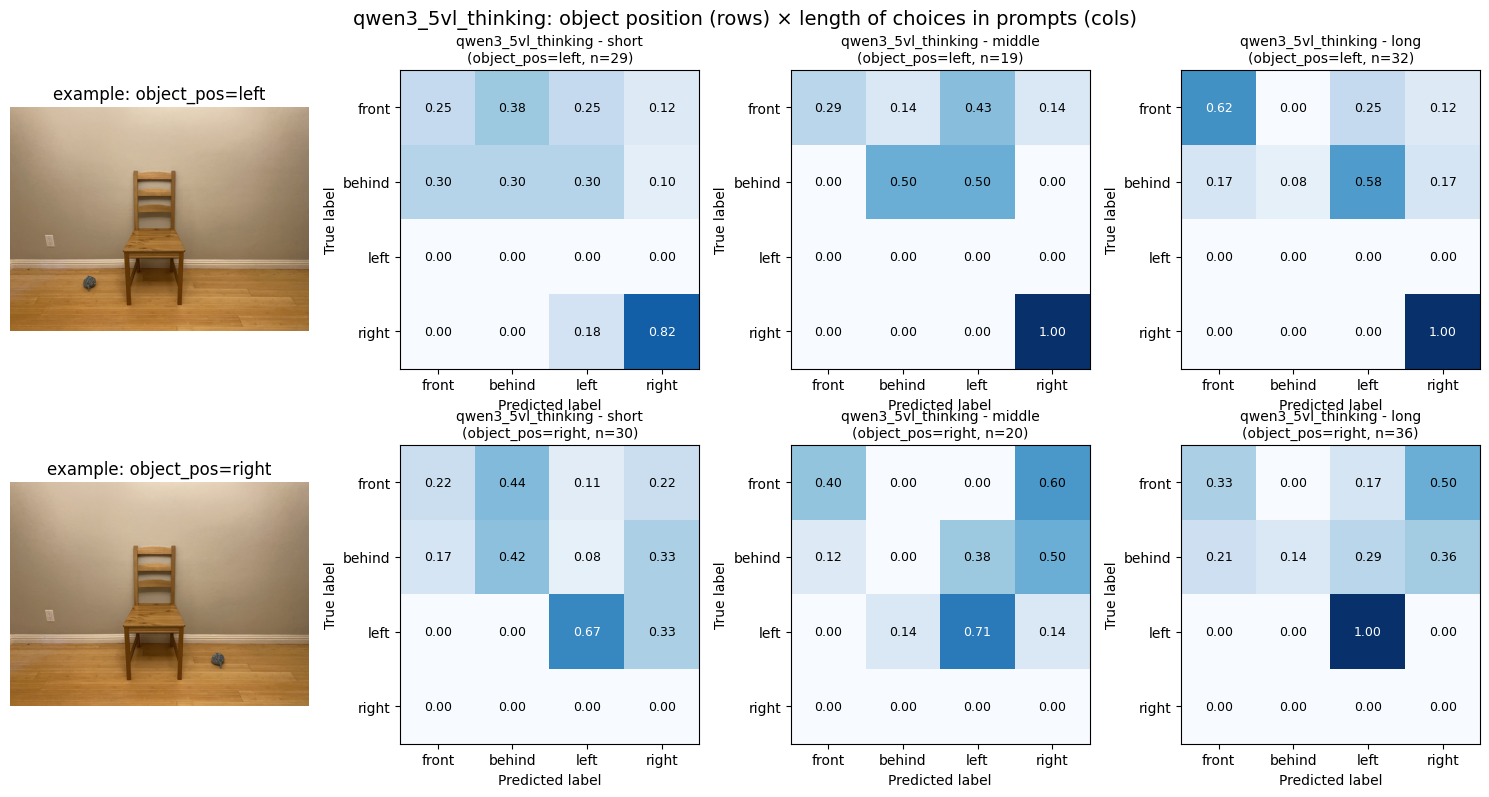

MODEL: gemma3


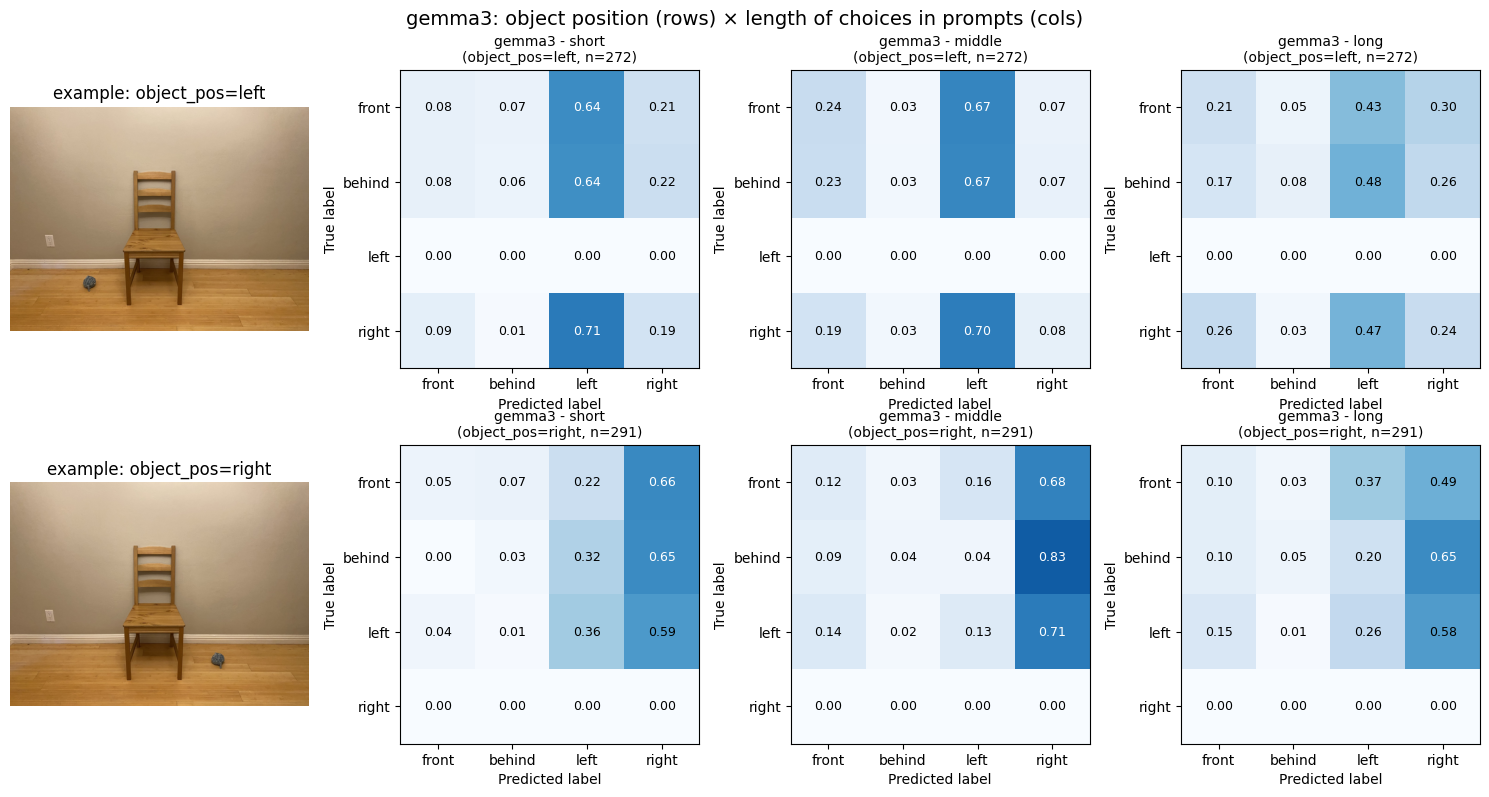

In [17]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["internvl", "qwen3vl", "qwen3vl_thinking", "qwen3.5", "qwen3_5vl_thinking", "gemma3"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        # display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }
    # 1张图，2行3列：第1行 object_pos=left，第2行 object_pos=right
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_left_of_chair.jpeg")
    axes[0][0].imshow(img)
    axes[0][0].axis("off")
    axes[0][0].set_title("example: object_pos=left")

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_right_of_chair.jpeg")
    axes[1][0].imshow(img)
    axes[1][0].axis("off")
    axes[1][0].set_title("example: object_pos=right")

    for i, length in enumerate(lengths):
        for j, obj_pos in enumerate(OBJECT_POSITIONS):
            ax = axes[j][i + 1]  # 列偏移+1，给图片列让位
            if length not in dfs:
                ax.axis("off")
                continue
            sub = dfs[length][dfs[length]["object_position"] == obj_pos]
            plot_confusion_on_ax(
                sub,
                ax,
                title=f"{model} - {length}\n(object_pos={obj_pos}, n={len(sub)})"
            )

    fig.suptitle(f"{model}: object position (rows) × length of choices in prompts (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()


### internvl

MODEL: internvl


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.011976,0.005988
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.071856,0.011976
1,behind,199,0.010050,0.030151
2,left,100,0.000000,0.980000
3,right,97,0.010309,0.979381


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.317365,0.023952
1,behind,199,0.045226,0.226131
2,left,100,0.020000,0.660000
3,right,97,0.010309,0.814433


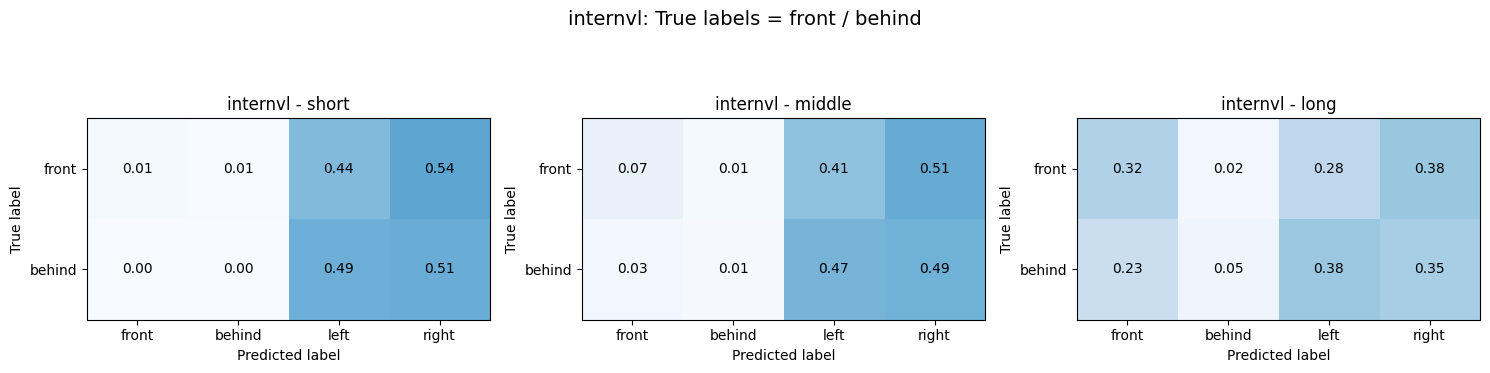

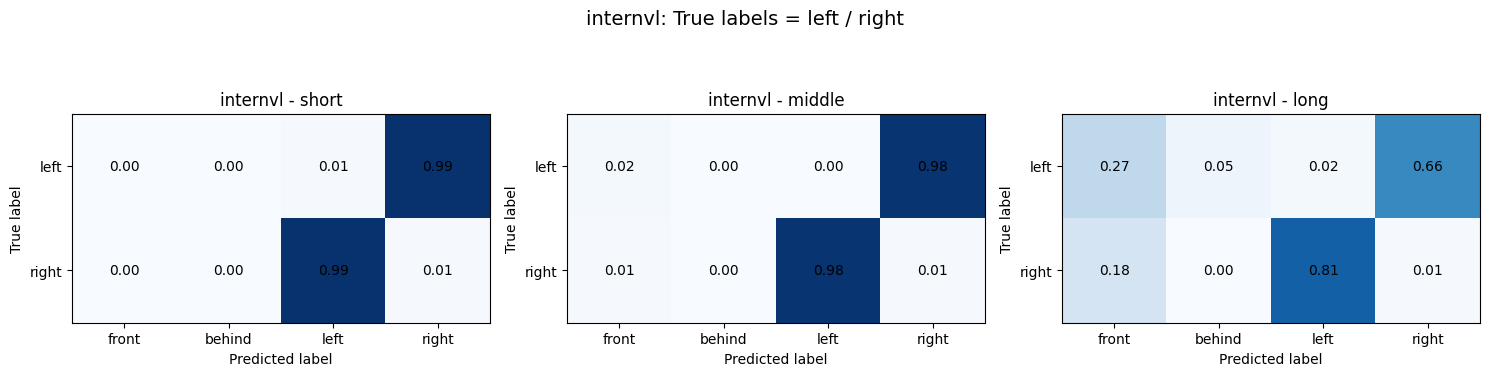

In [10]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["internvl"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

MODEL: internvl


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.011976,0.005988
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.071856,0.011976
1,behind,199,0.010050,0.030151
2,left,100,0.000000,0.980000
3,right,97,0.010309,0.979381


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.317365,0.023952
1,behind,199,0.045226,0.226131
2,left,100,0.020000,0.660000
3,right,97,0.010309,0.814433


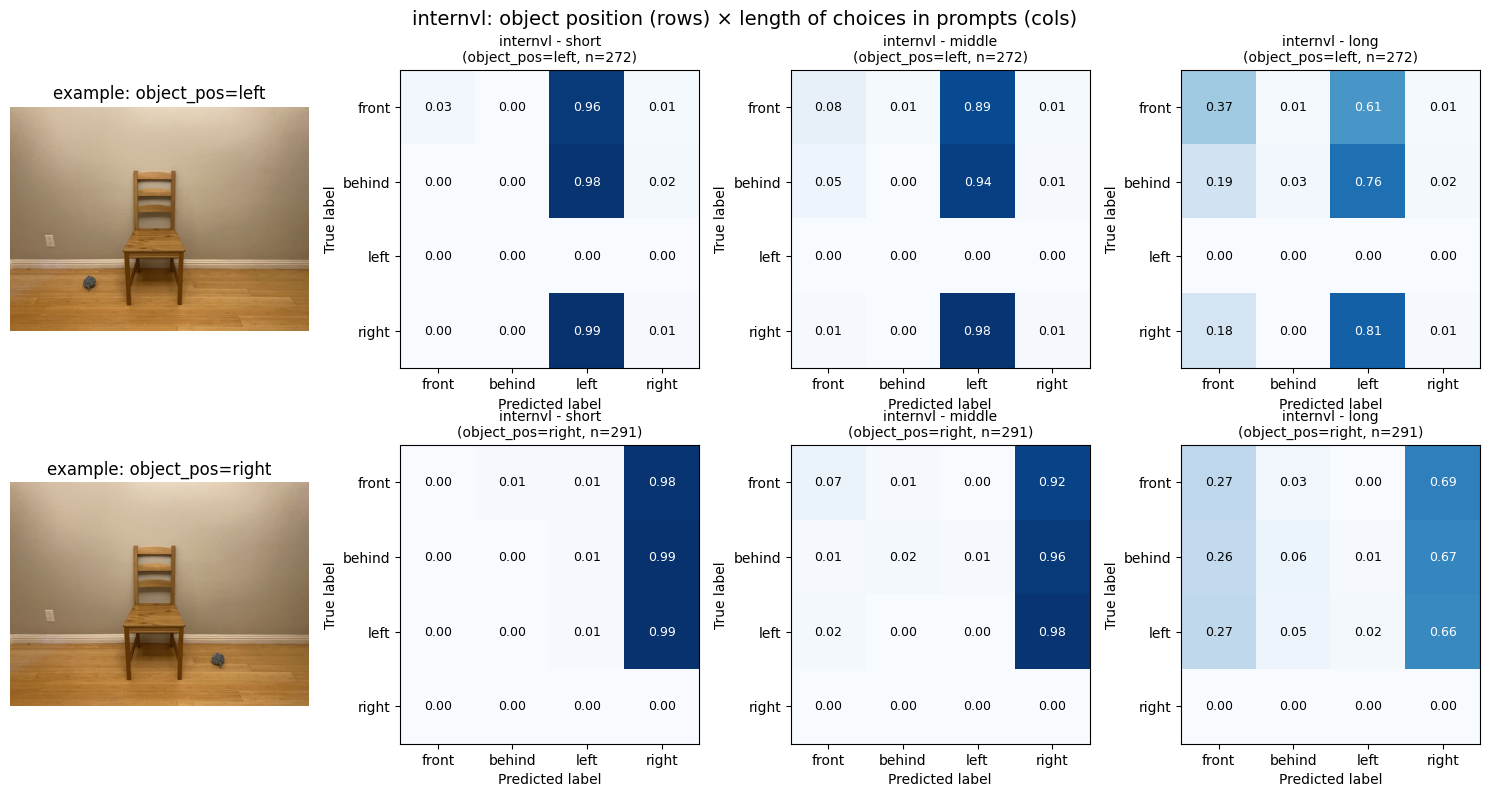

In [14]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["internvl"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }
    # 1张图，2行3列：第1行 object_pos=left，第2行 object_pos=right
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_left_of_chair.jpeg")
    axes[0][0].imshow(img)
    axes[0][0].axis("off")
    axes[0][0].set_title("example: object_pos=left")

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_right_of_chair.jpeg")
    axes[1][0].imshow(img)
    axes[1][0].axis("off")
    axes[1][0].set_title("example: object_pos=right")

    for i, length in enumerate(lengths):
        for j, obj_pos in enumerate(OBJECT_POSITIONS):
            ax = axes[j][i + 1]  # 列偏移+1，给图片列让位
            if length not in dfs:
                ax.axis("off")
                continue
            sub = dfs[length][dfs[length]["object_position"] == obj_pos]
            plot_confusion_on_ax(
                sub,
                ax,
                title=f"{model} - {length}\n(object_pos={obj_pos}, n={len(sub)})"
            )

    fig.suptitle(f"{model}: object position (rows) × length of choices in prompts (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()




    # # Figure 1: object_position = left，4×4 confusion matrix
    # fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # for i, length in enumerate(lengths):
    #     if length not in dfs:
    #         axes[i].axis("off")
    #         continue
    #     sub = dfs[length][dfs[length]["object_position"] == "left"]
    #     plot_confusion_on_ax(
    #         sub,
    #         axes[i],
    #         title=f"{model} - {length}\n(object_pos=left, n={len(sub)})"
    #     )
    # fig.suptitle(f"{model}: object position = left", fontsize=14)
    # plt.tight_layout()
    # plt.show()

    # # Figure 2: object_position = right，4×4 confusion matrix
    # fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # for i, length in enumerate(lengths):
    #     if length not in dfs:
    #         axes[i].axis("off")
    #         continue
    #     sub = dfs[length][dfs[length]["object_position"] == "right"]
    #     plot_confusion_on_ax(
    #         sub,
    #         axes[i],
    #         title=f"{model} - {length}\n(object_pos=right, n={len(sub)})"
    #     )
    # fig.suptitle(f"{model}: object position = right", fontsize=14)
    # plt.tight_layout()
    # plt.show()


MODEL: internvl

--- internvl | short ---


,correct_relation,total,correct_pct,camera_pct,other_pct
0,front,167,0.011976,0.970060,0.017964
1,behind,199,0.000000,0.984925,0.015075
2,left,100,0.010000,0.990000,0.000000
3,right,97,0.010309,0.989691,0.000000



--- internvl | middle ---


,correct_relation,total,correct_pct,camera_pct,other_pct
0,front,167,0.071856,0.910180,0.017964
1,behind,199,0.010050,0.949749,0.040201
2,left,100,0.000000,0.980000,0.020000
3,right,97,0.010309,0.979381,0.010309



--- internvl | long ---


,correct_relation,total,correct_pct,camera_pct,other_pct
0,front,167,0.317365,0.652695,0.029940
1,behind,199,0.045226,0.713568,0.241206
2,left,100,0.020000,0.660000,0.320000
3,right,97,0.010309,0.814433,0.175258


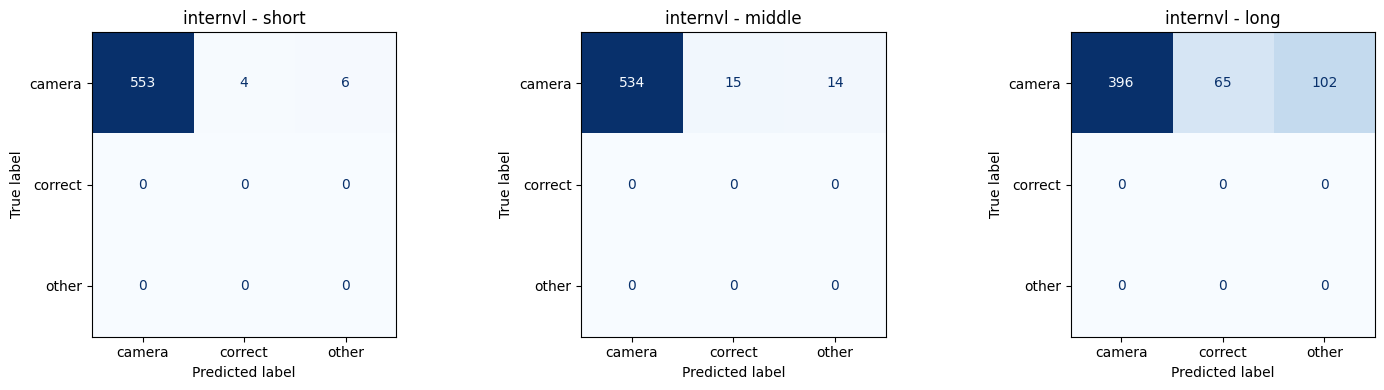

In [ ]:
# from collections import defaultdict
# import matplotlib.pyplot as plt

# base_dir = "./"
# lengths = ["short", "middle", "long"]
# models = ["internvl"]

# results = defaultdict(dict)

# for model in models:
#     print("\n" + "=" * 40)
#     print(f"MODEL: {model}")
#     print("=" * 40)

#     dfs = {}

#     for length in lengths:
#         csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")

#         if not os.path.exists(csv_path):
#             print(f"Missing file: {csv_path}")
#             continue

#         df = load_and_prepare(csv_path)
#         stat_df = analyze_camera_bias(df)

#         print(f"\n--- {model} | {length} ---")
#         display(stat_df)

#         dfs[length] = df
#         results[model][length] = {
#             "df": df,
#             "camera_stats": stat_df
#         }

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#     for i, length in enumerate(lengths):
#         if length not in dfs:
#             axes[i].axis("off")
#             continue

#         plot_camera_confusion(
#             dfs[length],
#             axes[i],
#             title=f"{model} - {length}"
#         )

#     plt.tight_layout()
#     plt.show()

### qwen3-vl

MODEL: qwen3vl


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.023952,0.000000
1,behind,199,0.000000,0.005025
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.000000,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.011976,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.030000,0.970000
3,right,97,0.010309,0.989691


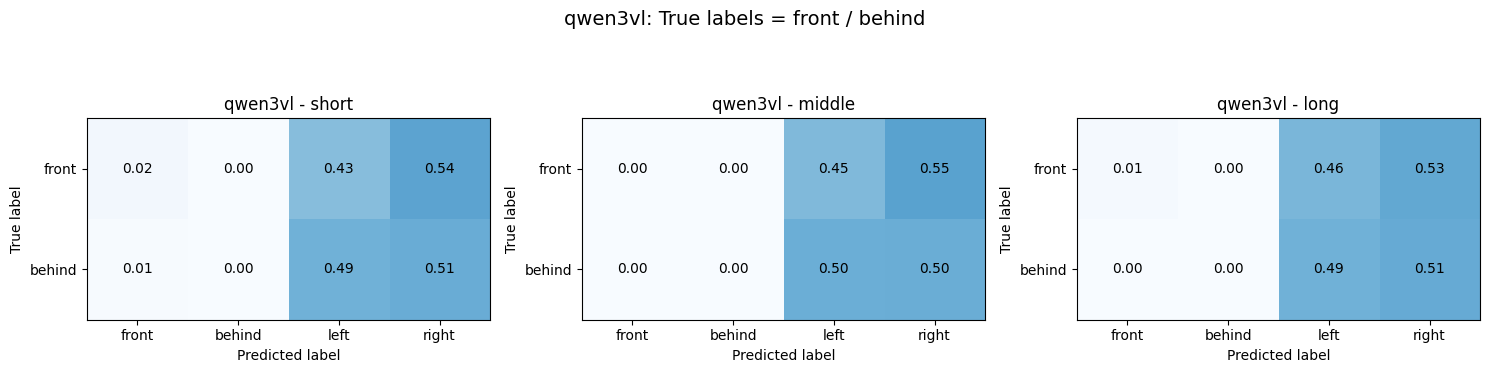

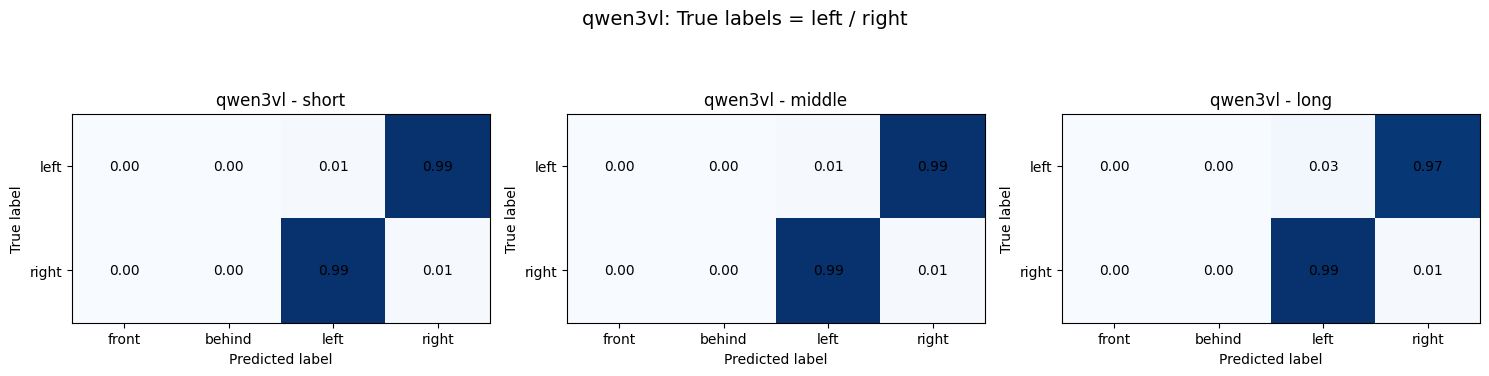

In [11]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3vl"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

MODEL: qwen3vl


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.023952,0.000000
1,behind,199,0.000000,0.005025
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.000000,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.011976,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.030000,0.970000
3,right,97,0.010309,0.989691


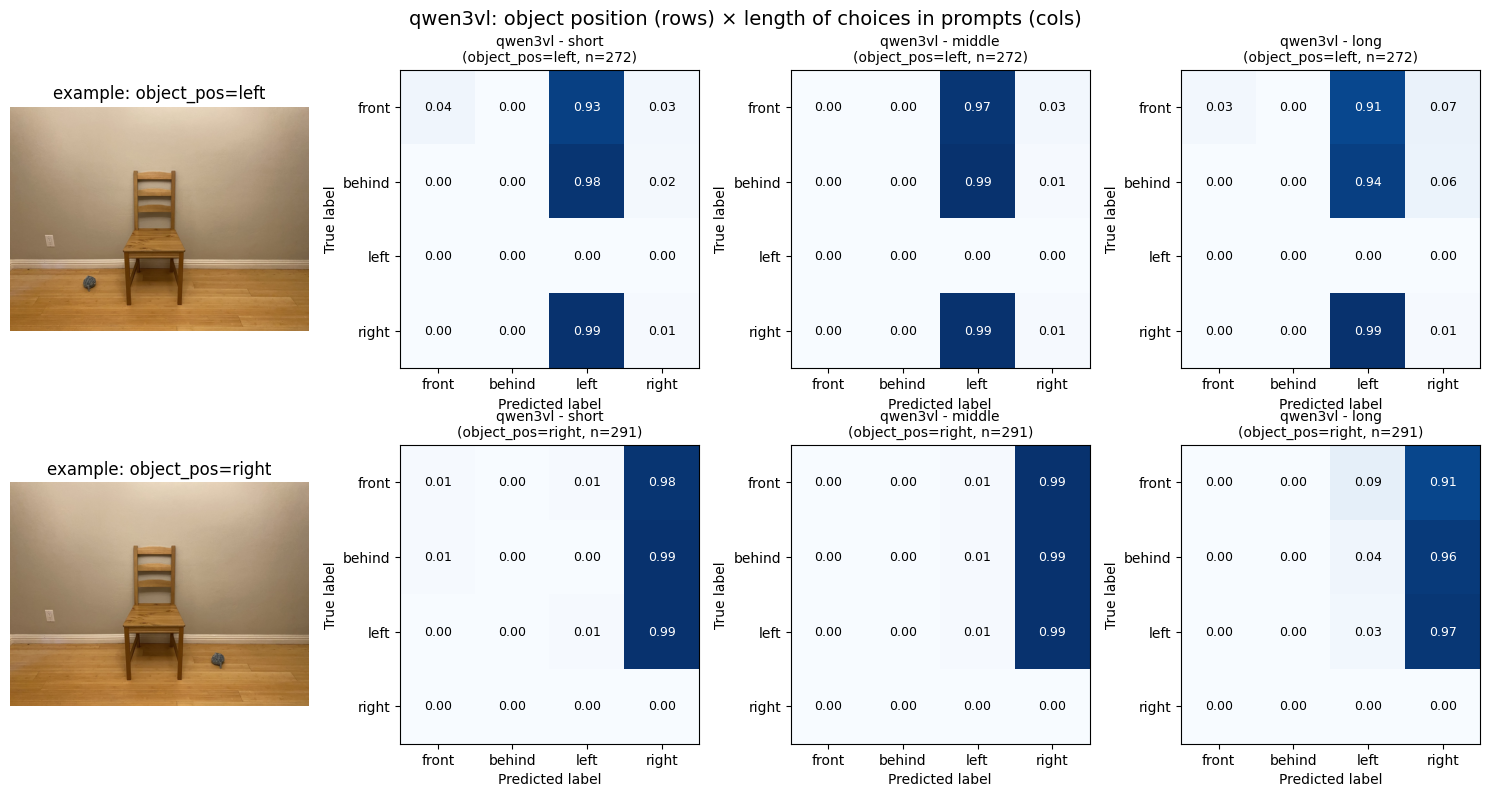

In [13]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3vl"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }
    # 1张图，2行3列：第1行 object_pos=left，第2行 object_pos=right
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_left_of_chair.jpeg")
    axes[0][0].imshow(img)
    axes[0][0].axis("off")
    axes[0][0].set_title("example: object_pos=left")

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_right_of_chair.jpeg")
    axes[1][0].imshow(img)
    axes[1][0].axis("off")
    axes[1][0].set_title("example: object_pos=right")

    for i, length in enumerate(lengths):
        for j, obj_pos in enumerate(OBJECT_POSITIONS):
            ax = axes[j][i + 1]  # 列偏移+1，给图片列让位
            if length not in dfs:
                ax.axis("off")
                continue
            sub = dfs[length][dfs[length]["object_position"] == obj_pos]
            plot_confusion_on_ax(
                sub,
                ax,
                title=f"{model} - {length}\n(object_pos={obj_pos}, n={len(sub)})"
            )

    fig.suptitle(f"{model}: object position (rows) × length of choices in prompts (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()



### qwen3-vl-thinking

MODEL: qwen3vl_thinking


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.017964,0.000000
1,behind,199,0.000000,0.005025
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.071856,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.035928,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


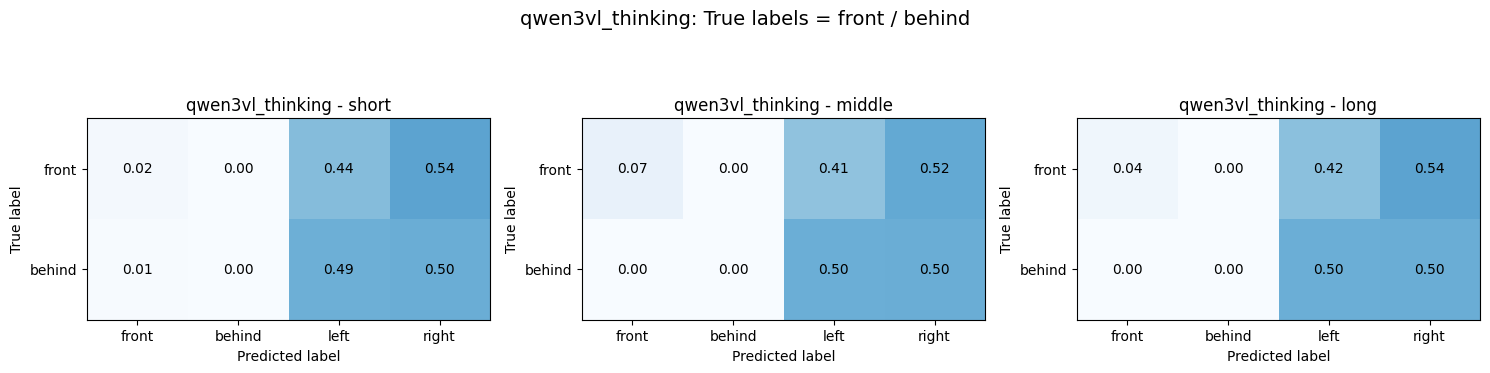

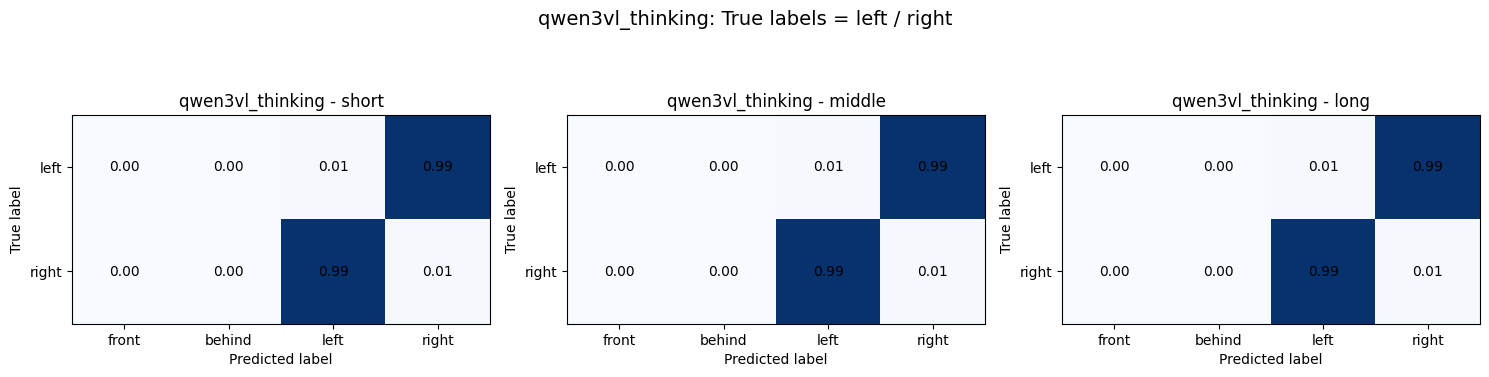

In [12]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3vl_thinking"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

MODEL: qwen3vl_thinking


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.017964,0.000000
1,behind,199,0.000000,0.005025
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.071856,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.035928,0.000000
1,behind,199,0.000000,0.000000
2,left,100,0.010000,0.990000
3,right,97,0.010309,0.989691


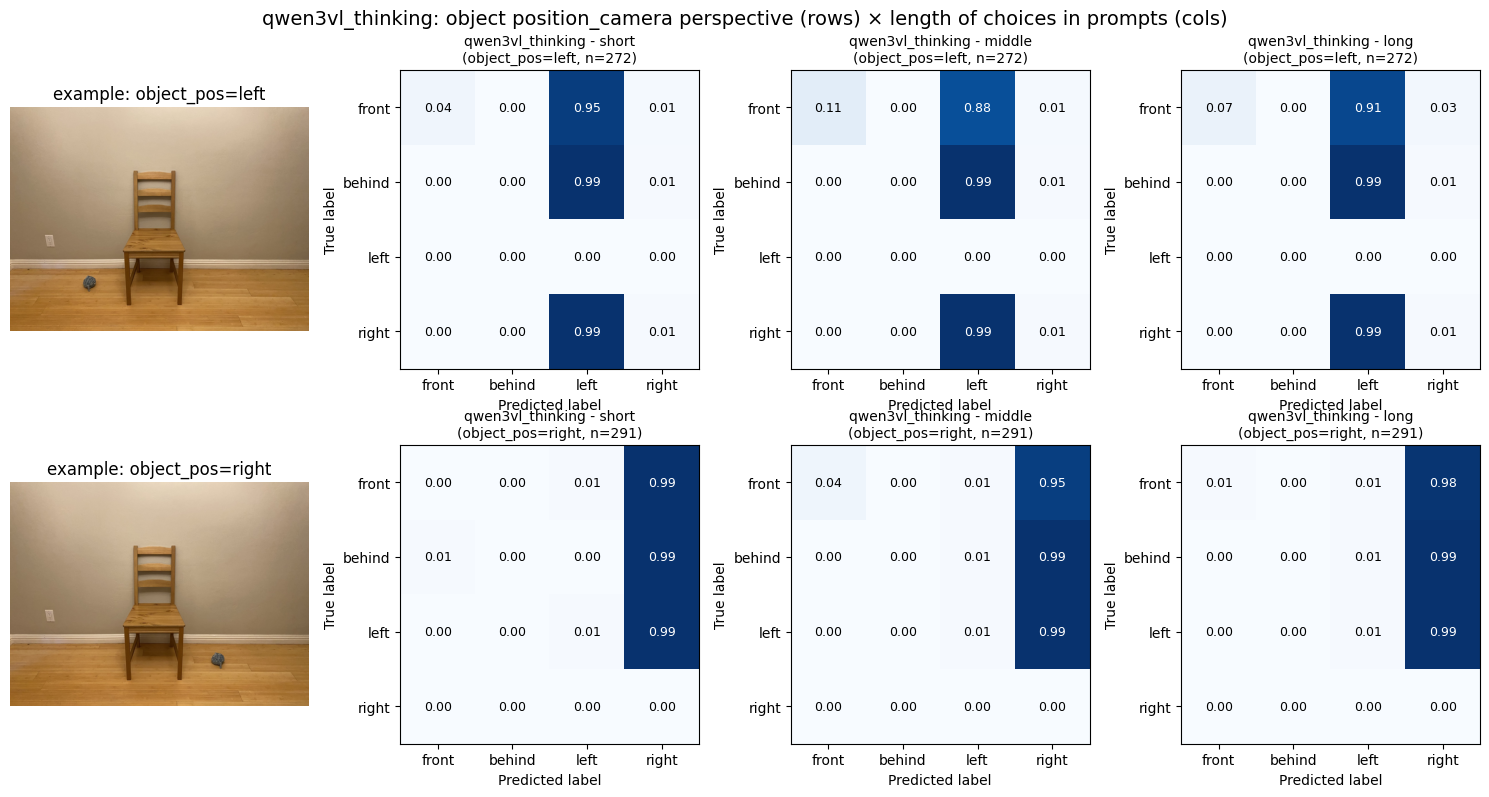

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3vl_thinking"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }
    # 1张图，2行3列：第1行 object_pos=left，第2行 object_pos=right
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_left_of_chair.jpeg")
    axes[0][0].imshow(img)
    axes[0][0].axis("off")
    axes[0][0].set_title("example: object_pos=left")

    img = plt.imread("/home/zzou/WhatsUp_dataset/controlled_images/ball-of-yarn_right_of_chair.jpeg")
    axes[1][0].imshow(img)
    axes[1][0].axis("off")
    axes[1][0].set_title("example: object_pos=right")

    for i, length in enumerate(lengths):
        for j, obj_pos in enumerate(OBJECT_POSITIONS):
            ax = axes[j][i + 1]  # 列偏移+1，给图片列让位
            if length not in dfs:
                ax.axis("off")
                continue
            sub = dfs[length][dfs[length]["object_position"] == obj_pos]
            plot_confusion_on_ax(
                sub,
                ax,
                title=f"{model} - {length}\n(object_pos={obj_pos}, n={len(sub)})"
            )

    # for i, length in enumerate(lengths):
    #     for j, obj_pos in enumerate(OBJECT_POSITIONS):

    #         ax = axes[j][i]
    #         if length not in dfs:
    #             ax.axis("off")
    #             continue
    #         sub = dfs[length][dfs[length]["object_position"] == obj_pos]
    #         plot_confusion_on_ax(
    #             sub,
    #             ax,
    #             title=f"{model} - {length}\n(object_pos={obj_pos}, n={len(sub)})"
    #         )

    fig.suptitle(f"{model}: object position (rows) × length of choices in prompts (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()



### Qwen3.5

MODEL: qwen3.5


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.173653,0.035928
1,behind,199,0.060302,0.080402
2,left,100,0.230000,0.730000
3,right,97,0.092784,0.824742


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.239521,0.071856
1,behind,199,0.050251,0.115578
2,left,100,0.010000,0.930000
3,right,97,0.072165,0.845361


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.155689,0.011976
1,behind,199,0.055276,0.065327
2,left,100,0.290000,0.690000
3,right,97,0.185567,0.783505


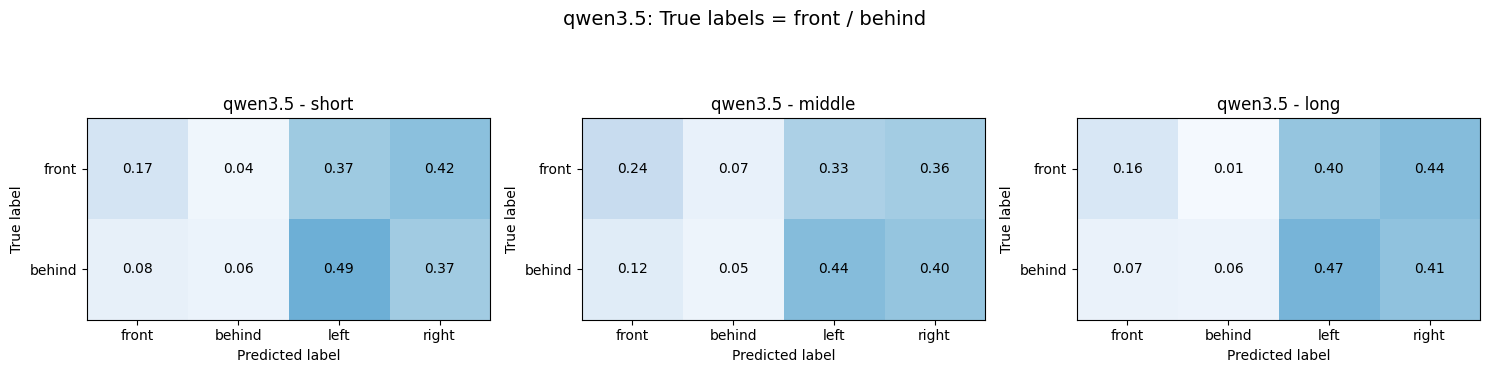

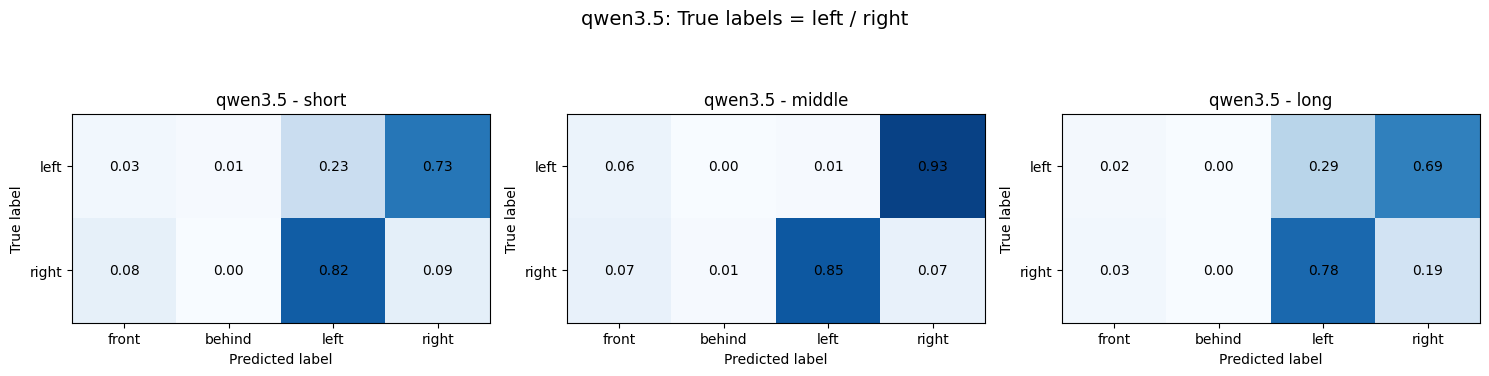

In [13]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3.5"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

MODEL: qwen3_5vl_thinking


,correct_relation,total,correct_pct,opposite_pct
0,front,17,0.235294,0.411765
1,behind,22,0.363636,0.227273
2,left,9,0.666667,0.333333
3,right,11,0.818182,0.181818


,correct_relation,total,correct_pct,opposite_pct
0,front,20,0.450000,0.000000
1,behind,26,0.115385,0.192308
2,left,10,1.000000,0.000000
3,right,12,1.000000,0.000000


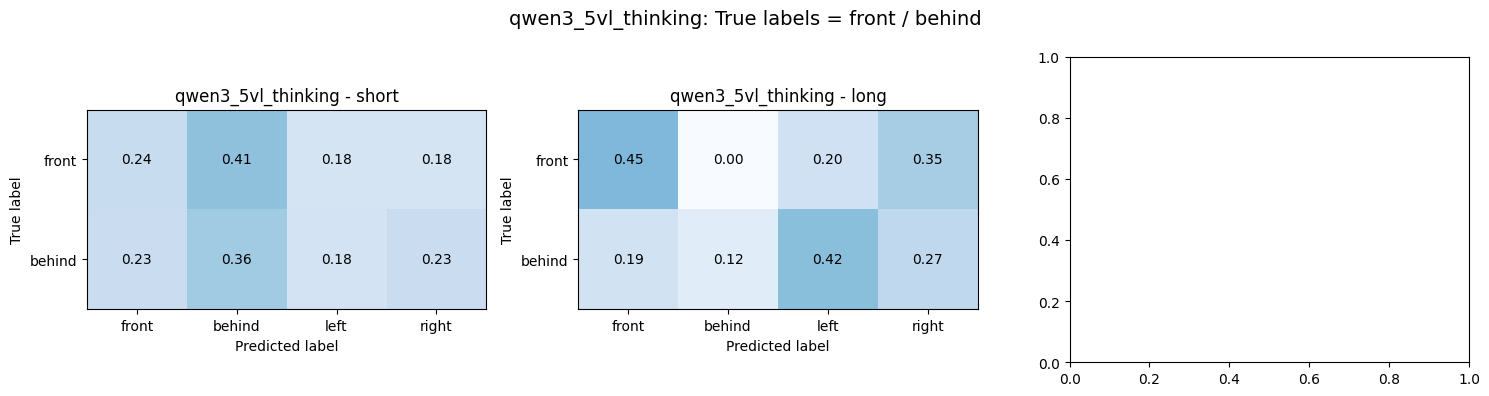

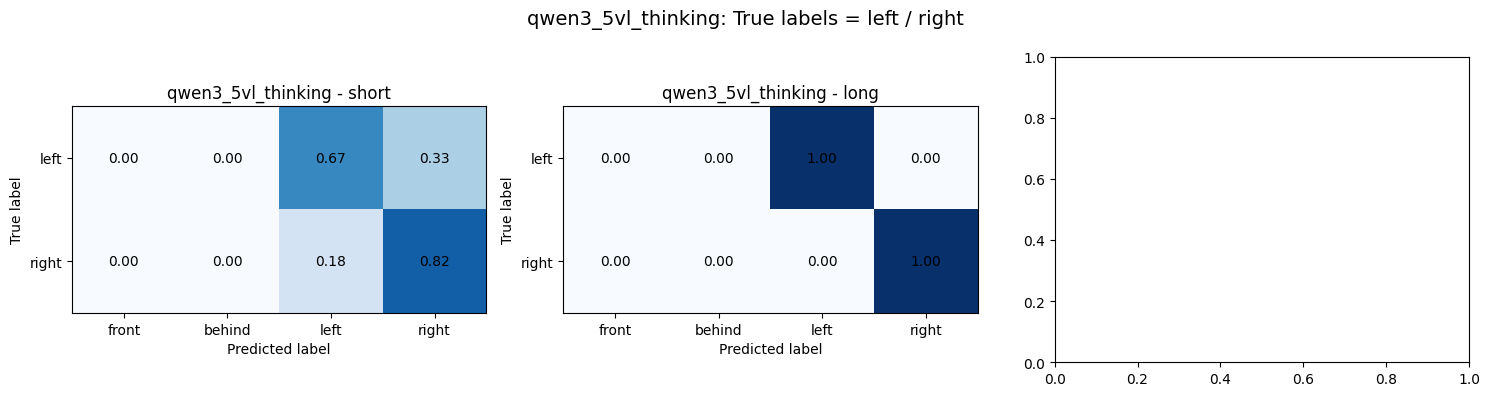

In [2]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short",  "long"]
models = ["qwen3_5vl_thinking"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

### Gemma3-12B

MODEL: gemma3


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.065868,0.065868
1,behind,199,0.045226,0.040201
2,left,100,0.360000,0.590000
3,right,97,0.185567,0.711340


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.173653,0.029940
1,behind,199,0.035176,0.160804
2,left,100,0.130000,0.710000
3,right,97,0.082474,0.701031


,correct_relation,total,correct_pct,opposite_pct
0,front,167,0.149701,0.041916
1,behind,199,0.065327,0.135678
2,left,100,0.260000,0.580000
3,right,97,0.237113,0.474227


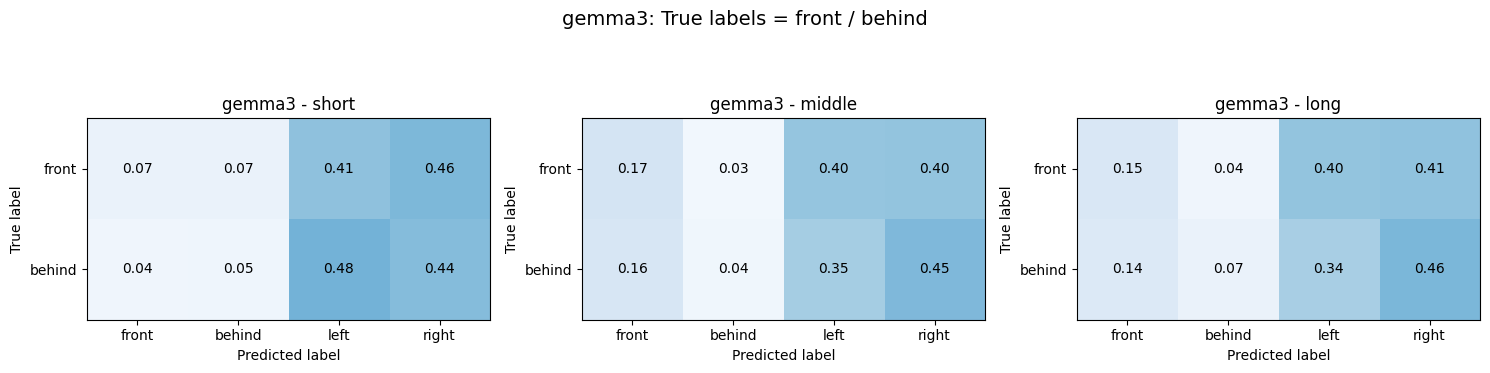

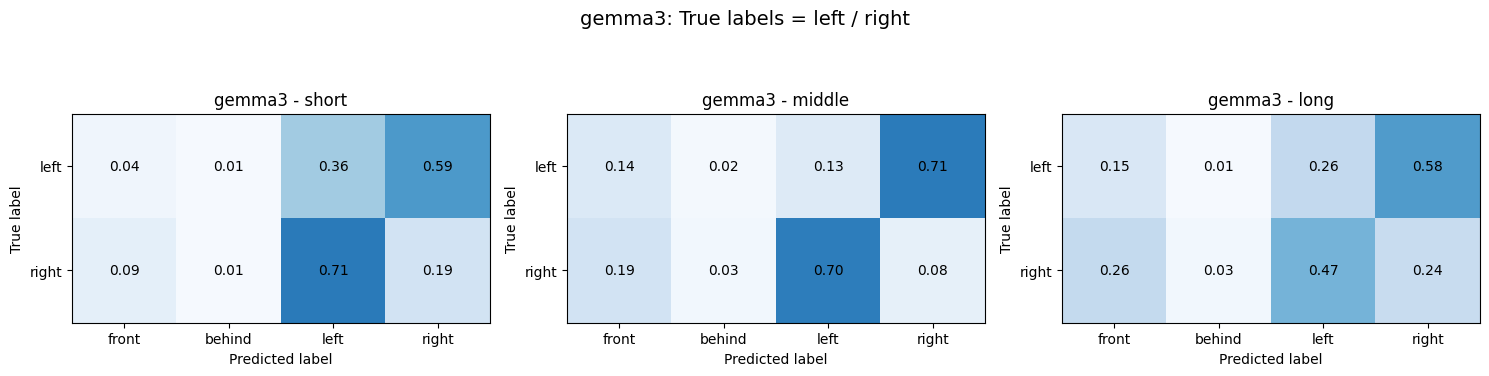

In [14]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["gemma3"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()